<a href="https://colab.research.google.com/github/Sammy-Shieunda/Dysgraphia-screening-capstone/blob/main/01_data_exploration.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Loading and Quality Checks
### Early Dysgraphia Screening from Handwriting — Potential Dysgraphia Handwriting Dataset (PDM)

**CRISP-DM phase:** Data Understanding

**Purpose of this notebook**

Before any modelling can happen, we need to be confident about *what* is actually in the dataset. For a tabular dataset you'd reach for `df.shape` and `df.describe()` to get an instant feel for size, structure and distribution. Images don't have rows and columns of numbers in the same way, so this notebook builds the **image equivalent**:


Specifically, this notebook:

1. **Loads the dataset** into a single tabular index (one row per image) so every later step can just operate on a DataFrame.
2. **Counts images per class** (`Potential Dysgraphia` vs `Low Potential Dysgraphia`) — this tells us whether the classes are balanced, which directly affects how we should evaluate the model later (recall on the minority/at-risk class is the metric this project cares about most).
3. **Checks colour mode and dimensions** — every image needs to be the same shape and channel depth before it can be fed to a CNN, so we need to know how much resizing/normalising work lies ahead.
4. **Checks for corrupted files** — a single unreadable image can crash a training loop hours into a run if it isn't caught here first.
5. **Checks for duplicate files** — duplicates that end up split across the train/validation/test sets cause **data leakage**, which quietly inflates evaluation metrics.
6. **Produces a Data Quality Summary** — a single consolidated report you can drop straight into your project documentation and reference when your lecturer asks "how do you know the data is clean?"


## 1. Setup and Imports

We only need standard libraries plus `Pillow` (image handling) and `pandas`/`matplotlib` (the same tools you'd use for tabular EDA). Keeping the dependency list small makes this easy to run in Colab or a plain local environment.


In [1]:
import os
import hashlib
from pathlib import Path
from collections import defaultdict

import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image

# Make plots a bit more readable by default
plt.rcParams["figure.dpi"] = 100
pd.set_option("display.max_colwidth", 60)


In [3]:
# CONFIG — update this path to match where you unzipped the dataset

DATASET_ROOT = Path("DATASET DYSGRAPHIA HANDWRITING")  # folder containing the two class subfolders

# Sanity check that the path exists before we go any further
assert DATASET_ROOT.exists(), (
    f"Could not find '{DATASET_ROOT}'. Update DATASET_ROOT to point at the "
    f"unzipped dataset folder (the one that directly contains the class subfolders)."
)

CLASS_DIRS = sorted([d for d in DATASET_ROOT.iterdir() if d.is_dir()])
print(f"Found {len(CLASS_DIRS)} class folders:")
for d in CLASS_DIRS:
    print(" -", d.name)


Found 2 class folders:
 - Low Potential Dysgraphia
 - Potential Dysgraphia


## 2. Load the Dataset Index — the image equivalent of `df.shape`


In [4]:
def build_dataset_index(dataset_root: Path) -> pd.DataFrame:
    '''Walk the dataset folder and build one row per image file.'''
    valid_extensions = {".jpg", ".jpeg", ".png", ".bmp", ".gif", ".tiff"}
    records = []
    for class_dir in sorted([d for d in dataset_root.iterdir() if d.is_dir()]):
        for file_path in sorted(class_dir.glob("*")):
            if file_path.is_file() and file_path.suffix.lower() in valid_extensions:
                records.append({
                    "filepath": str(file_path),
                    "filename": file_path.name,
                    "class_label": class_dir.name,
                    "file_size_kb": round(file_path.stat().st_size / 1024, 2),
                })
    return pd.DataFrame(records)


df = build_dataset_index(DATASET_ROOT)

print(f"Dataset shape (image equivalent of df.shape): {df.shape}")
print(f"  -> {df.shape[0]} images, {df.shape[1]} metadata fields collected so far")
df.head()

Dataset shape (image equivalent of df.shape): (249, 4)
  -> 249 images, 4 metadata fields collected so far


,filepath,filename,class_label,file_size_kb
0,DATASET DYSGRAPHIA HANDWRITING\Low Potential Dysgraphia\...,LPD (1).jpg,Low Potential Dysgraphia,10.64
1,DATASET DYSGRAPHIA HANDWRITING\Low Potential Dysgraphia\...,LPD (10).jpg,Low Potential Dysgraphia,9.34
2,DATASET DYSGRAPHIA HANDWRITING\Low Potential Dysgraphia\...,LPD (100).jpg,Low Potential Dysgraphia,23.83
3,DATASET DYSGRAPHIA HANDWRITING\Low Potential Dysgraphia\...,LPD (101).jpg,Low Potential Dysgraphia,47.69
4,DATASET DYSGRAPHIA HANDWRITING\Low Potential Dysgraphia\...,LPD (102).jpg,Low Potential Dysgraphia,85.77


## 3. Image Counts per Class


In [5]:
class_counts = df["class_label"].value_counts()
class_pct = df["class_label"].value_counts(normalize=True) * 100

summary_table = pd.DataFrame({
    "count": class_counts,
    "percentage": class_pct.round(1)
})
print(summary_table)

imbalance_ratio = class_counts.max() / class_counts.min()
print(f"\nClass imbalance ratio (majority:minority): {imbalance_ratio:.2f} : 1")

                          count  percentage
class_label                                
Low Potential Dysgraphia    135        54.2
Potential Dysgraphia        114        45.8

Class imbalance ratio (majority:minority): 1.18 : 1


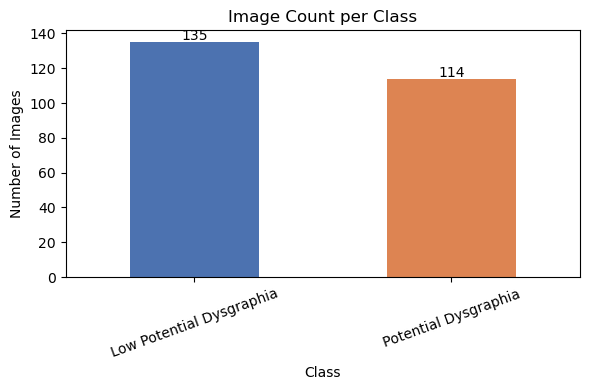

In [6]:
fig, ax = plt.subplots(figsize=(6, 4))
class_counts.plot(kind="bar", ax=ax, color=["#4C72B0", "#DD8452"])
ax.set_title("Image Count per Class")
ax.set_xlabel("Class")
ax.set_ylabel("Number of Images")
ax.tick_params(axis="x", rotation=20)
for i, v in enumerate(class_counts):
    ax.text(i, v + 1, str(v), ha="center")
plt.tight_layout()
plt.show()


## 4. Corrupted / Unreadable File Check


In [7]:
def is_corrupted(filepath: str) -> bool:
    '''Return True if the image file cannot be verified as a valid image.'''
    try:
        with Image.open(filepath) as img:
            img.verify()
        return False
    except Exception:
        return True


df["is_corrupted"] = df["filepath"].apply(is_corrupted)

n_corrupted = df["is_corrupted"].sum()
print(f"Corrupted files found: {n_corrupted} / {len(df)}")

if n_corrupted > 0:
    display(df.loc[df["is_corrupted"], ["filepath", "class_label"]])
else:
    print("No corrupted files detected — safe to proceed to the next check.")

Corrupted files found: 0 / 249
No corrupted files detected — safe to proceed to the next check.


## 5. Duplicate File Check



In [8]:
def file_md5(filepath: str) -> str:
    hasher = hashlib.md5()
    with open(filepath, "rb") as f:
        hasher.update(f.read())
    return hasher.hexdigest()


df["md5_hash"] = df["filepath"].apply(file_md5)

duplicate_mask = df["md5_hash"].duplicated(keep=False)
n_duplicate_files = duplicate_mask.sum()
n_duplicate_groups = df.loc[duplicate_mask, "md5_hash"].nunique()

print(f"Duplicate files found: {n_duplicate_files} (across {n_duplicate_groups} duplicate groups)")

if n_duplicate_files > 0:
    dupe_groups = df.loc[duplicate_mask].sort_values("md5_hash")
    display(dupe_groups[["filepath", "class_label", "md5_hash"]])

    cross_class_leak = (
        dupe_groups.groupby("md5_hash")["class_label"].nunique() > 1
    ).sum()
    print(f"Duplicate groups spanning MORE THAN ONE class (potential label conflict): {cross_class_leak}")
else:
    print("No exact duplicate files detected.")

Duplicate files found: 0 (across 0 duplicate groups)
No exact duplicate files detected.


## 6. Sample Dimensions and Colour Mode

Every image needs to enter the CNN as a fixed-size tensor with a known number of channels, so we need to know:

- **Width / height** — are all images the same size, or will every image need resizing before training?
- **Colour mode** — `L` = single-channel grayscale, `RGB` = 3-channel colour, `RGBA` = colour + transparency. Many pretrained ImageNet backbones (ResNet, VGG, EfficientNet, etc. — exactly the kind of transfer-learning backbone this project plans to use) expect 3-channel RGB input, so if these scans are grayscale, that's a preprocessing step to plan for now rather than discover mid-training.


In [9]:
def get_image_properties(filepath: str):
    '''Return (width, height, colour_mode, format) for a valid image, or Nones if unreadable.'''
    try:
        with Image.open(filepath) as img:
            return img.width, img.height, img.mode, img.format
    except Exception:
        return None, None, None, None


# Only inspect files that passed the corruption check
props = df["filepath"].apply(get_image_properties)
df["width"] = props.apply(lambda t: t[0])
df["height"] = props.apply(lambda t: t[1])
df["color_mode"] = props.apply(lambda t: t[2])
df["file_format"] = props.apply(lambda t: t[3])
df["aspect_ratio"] = (df["width"] / df["height"]).round(2)

df[["filename", "class_label", "width", "height", "aspect_ratio", "color_mode", "file_format"]].head()

,filename,class_label,width,height,aspect_ratio,color_mode,file_format
0,LPD (1).jpg,Low Potential Dysgraphia,506,55,9.20,L,JPEG
1,LPD (10).jpg,Low Potential Dysgraphia,396,59,6.71,L,JPEG
2,LPD (100).jpg,Low Potential Dysgraphia,798,97,8.23,L,JPEG
3,LPD (101).jpg,Low Potential Dysgraphia,1250,165,7.58,L,JPEG
4,LPD (102).jpg,Low Potential Dysgraphia,1175,259,4.54,L,JPEG


In [10]:
print("File format(s) present:")
print(df["file_format"].value_counts(), "\n")

print("Colour mode(s) present:")
print(df["color_mode"].value_counts(), "\n")

print("Unique (width, height) pairs:", df[["width", "height"]].drop_duplicates().shape[0], "out of", len(df), "images")

File format(s) present:
file_format
JPEG    249
Name: count, dtype: int64 

Colour mode(s) present:
color_mode
L    249
Name: count, dtype: int64 

Unique (width, height) pairs: 246 out of 249 images


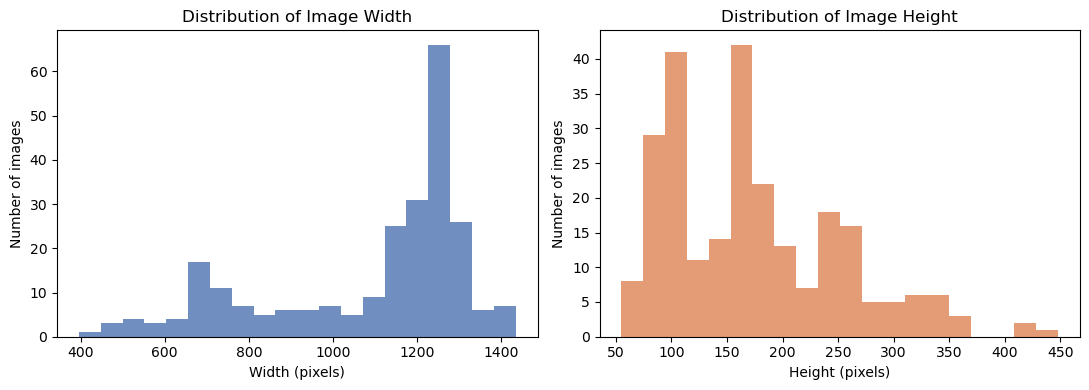

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

axes[0].hist(df["width"], bins=20, color="#4C72B0", alpha=0.8)
axes[0].set_title("Distribution of Image Width")
axes[0].set_xlabel("Width (pixels)")
axes[0].set_ylabel("Number of images")

axes[1].hist(df["height"], bins=20, color="#DD8452", alpha=0.8)
axes[1].set_title("Distribution of Image Height")
axes[1].set_xlabel("Height (pixels)")
axes[1].set_ylabel("Number of images")

plt.tight_layout()
plt.show()

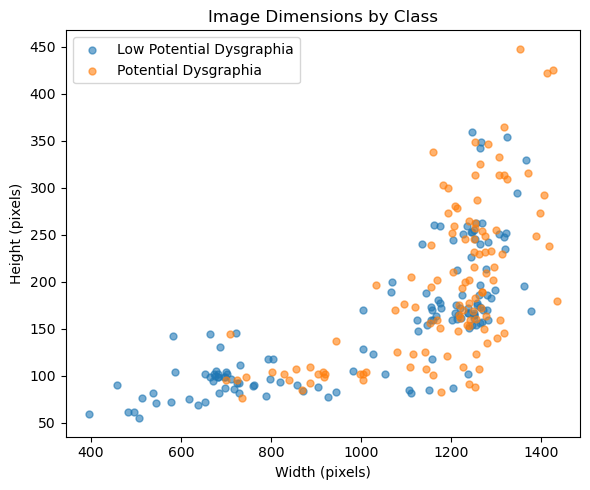

In [12]:
fig, ax = plt.subplots(figsize=(6, 5))
for label, group in df.groupby("class_label"):
    ax.scatter(group["width"], group["height"], label=label, alpha=0.6, s=25)
ax.set_xlabel("Width (pixels)")
ax.set_ylabel("Height (pixels)")
ax.set_title("Image Dimensions by Class")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Data Quality Summary — the Image Equivalent of `df.describe()`

This is the consolidated report: run `describe()` on the numeric image properties we've collected (width, height, aspect ratio, file size), then assemble everything above into one summary block you can paste directly into your project documentation.

In [13]:
numeric_summary = df[["width", "height", "aspect_ratio", "file_size_kb"]].describe().round(2)
numeric_summary

,width,height,aspect_ratio,file_size_kb
count,249.00,249.00,249.00,249.00
mean,1090.59,173.94,7.04,58.47
std,244.59,78.86,2.19,37.91
min,396.00,55.00,3.02,9.34
25%,918.00,102.00,5.31,29.39
50%,1204.00,164.00,6.95,47.69
75%,1258.00,230.00,8.10,80.77
max,1434.00,448.00,14.24,201.68


In [14]:
print("=" * 70)
print("DATA QUALITY SUMMARY — Potential Dysgraphia Handwriting Dataset")
print("=" * 70)

print(f"\nTotal images loaded:            {len(df)}")
print("Images per class:")
for label, count in class_counts.items():
    print(f"  - {label:<28} {count}  ({count/len(df)*100:.1f}%)")
print(f"Class imbalance ratio:           {imbalance_ratio:.2f} : 1")

print(f"\nCorrupted / unreadable files:    {n_corrupted}")
print(f"Exact duplicate files:           {n_duplicate_files}  ({n_duplicate_groups} groups)")

print(f"\nFile format(s):                  {', '.join(df['file_format'].dropna().unique())}")
print(f"Colour mode(s):                  {', '.join(df['color_mode'].dropna().unique())}")

print(f"\nWidth  (min / mean / max):       {df['width'].min()} / {df['width'].mean():.0f} / {df['width'].max()} px")
print(f"Height (min / mean / max):       {df['height'].min()} / {df['height'].mean():.0f} / {df['height'].max()} px")
print(f"Aspect ratio (min / mean / max): {df['aspect_ratio'].min():.2f} / {df['aspect_ratio'].mean():.2f} / {df['aspect_ratio'].max():.2f}")
print(f"File size KB (min / mean / max): {df['file_size_kb'].min():.1f} / {df['file_size_kb'].mean():.1f} / {df['file_size_kb'].max():.1f}")

print(f"\nUnique dimensions:               {df[['width','height']].drop_duplicates().shape[0]} distinct (width, height) pairs across {len(df)} images")
print("=" * 70)


DATA QUALITY SUMMARY — Potential Dysgraphia Handwriting Dataset

Total images loaded:            249
Images per class:
  - Low Potential Dysgraphia     135  (54.2%)
  - Potential Dysgraphia         114  (45.8%)
Class imbalance ratio:           1.18 : 1

Corrupted / unreadable files:    0
Exact duplicate files:           0  (0 groups)

File format(s):                  JPEG
Colour mode(s):                  L

Width  (min / mean / max):       396 / 1091 / 1434 px
Height (min / mean / max):       55 / 174 / 448 px
Aspect ratio (min / mean / max): 3.02 / 7.04 / 14.24
File size KB (min / mean / max): 9.3 / 58.5 / 201.7

Unique dimensions:               246 distinct (width, height) pairs across 249 images


## 8. Visual Sanity Check

Numbers can miss things a human eye catches instantly — a scan rotated 90°, a folder with the wrong images in it, heavy compression artefacts. A quick visual grid, sampled per class, is a cheap final check before moving on to preprocessing and modelling.

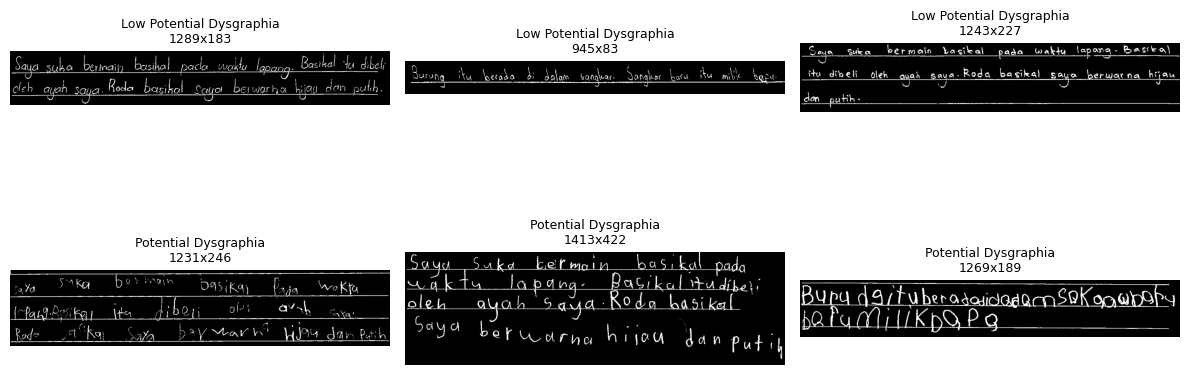

In [15]:
def show_sample_grid(dataframe: pd.DataFrame, n_per_class: int = 3):
    classes = dataframe["class_label"].unique()
    fig, axes = plt.subplots(len(classes), n_per_class, figsize=(4 * n_per_class, 3 * len(classes)))
    if len(classes) == 1:
        axes = [axes]

    for row, class_name in enumerate(classes):
        sample = dataframe[dataframe["class_label"] == class_name].sample(
            min(n_per_class, (dataframe["class_label"] == class_name).sum()),
            random_state=42
        )
        for col, (_, row_data) in enumerate(sample.iterrows()):
            ax = axes[row][col] if len(classes) > 1 else axes[col]
            img = Image.open(row_data["filepath"])
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{class_name}\n{row_data['width']}x{row_data['height']}", fontsize=9)
            ax.axis("off")

    plt.tight_layout()
    plt.show()


show_sample_grid(df, n_per_class=3)


## 9. Save the Dataset Index and Quality Report

Save the enriched index (with every column we computed) as a CSV. This becomes the reusable reference table for the rest of the project — later notebooks (preprocessing, augmentation, modelling) can load this file instead of re-scanning the raw images every time.


In [16]:
OUTPUT_DIR = Path("outputs")
OUTPUT_DIR.mkdir(exist_ok=True)

index_path = OUTPUT_DIR / "dataset_index_with_quality_checks.csv"
df.to_csv(index_path, index=False)
print(f"Saved enriched dataset index to: {index_path}")

report_path = OUTPUT_DIR / "data_quality_summary.txt"
with open(report_path, "w") as f:
    f.write("DATA QUALITY SUMMARY - Potential Dysgraphia Handwriting Dataset\n")
    f.write("=" * 65 + "\n")
    f.write(f"Total images: {len(df)}\n")
    for label, count in class_counts.items():
        f.write(f"  {label}: {count} ({count/len(df)*100:.1f}%)\n")
    f.write(f"Corrupted files: {n_corrupted}\n")
    f.write(f"Duplicate files: {n_duplicate_files} ({n_duplicate_groups} groups)\n")
    f.write(f"Colour mode(s): {', '.join(df['color_mode'].dropna().unique())}\n")
    f.write(f"Width range: {df['width'].min()}-{df['width'].max()} px (mean {df['width'].mean():.0f})\n")
    f.write(f"Height range: {df['height'].min()}-{df['height'].max()} px (mean {df['height'].mean():.0f})\n")
print(f"Saved plain-text quality report to: {report_path}")


Saved enriched dataset index to: outputs\dataset_index_with_quality_checks.csv
Saved plain-text quality report to: outputs\data_quality_summary.txt


## 10. Summary and Next Steps

This notebook establishes the **Data Understanding** foundation for the project:

- **Loaded** 249 handwriting sample images across 2 classes (`Low Potential Dysgraphia`, `Potential Dysgraphia`).
- **Verified integrity**: 0 corrupted files, 0 exact duplicates (checked across class boundaries).
- **Characterised the images**: all grayscale (`L` mode) JPEGs with variable width/height and aspect ratio.
- **Quantified class balance**: mild imbalance (~1.2:1), flagged as relevant to the recall-focused evaluation strategy in the project brief.
- **Produced a reusable index** (`outputs/dataset_index_with_quality_checks.csv`) that downstream notebooks can build on directly.

**This feeds into the next stage of the project:**
1. Preprocessing — resize/pad to a fixed input size, convert grayscale → RGB for the pretrained backbone, normalise pixel values.
2. Train / validation / test split — stratified by class to preserve the ~54/46 balance, and *after* confirming (as done here) that there's no duplicate leakage across the split.
3. Data augmentation — planned in the project brief to help the CNN generalise given a relatively small dataset (249 images total).
